In [1]:
import pandas as pd

df = pd.read_csv("data/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

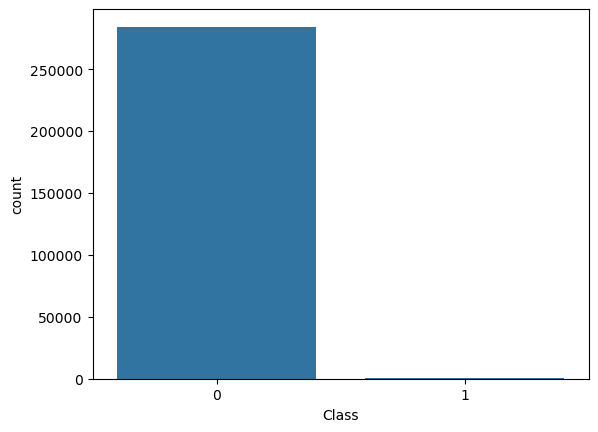

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Class", data=df)

plt.show()

In [4]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
from imblearn.over_sampling import SMOTE

In [6]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [7]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [8]:
y_resampled.value_counts()

Class
0    284315
1    284315
Name: count, dtype: int64

In [9]:
from sklearn.ensemble import IsolationForest

In [10]:
iso = IsolationForest(
    contamination=0.0017,
    random_state=42
)

iso.fit(X)

IsolationForest(contamination=0.0017, random_state=42)

In [12]:
pred = iso.predict(X)

In [13]:
pred = [1 if x == -1 else 0 for x in pred]

In [14]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y,
        pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.26      0.25      0.26       492

    accuracy                           1.00    284807
   macro avg       0.63      0.63      0.63    284807
weighted avg       1.00      1.00      1.00    284807



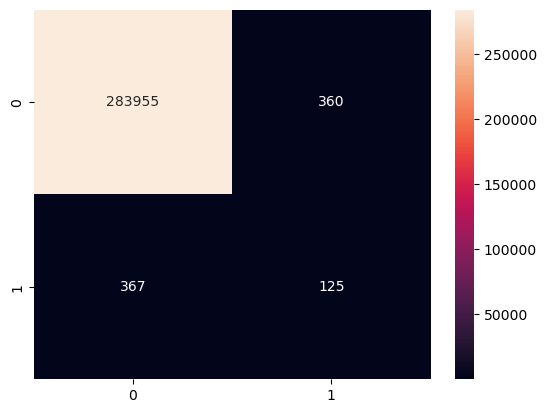

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

In [18]:
print(type(pred))
print(len(pred))

<class 'list'>
284807


In [19]:
import pandas as pd

pred = pd.Series(pred)

alerts = df[pred == 1]

alerts.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
1632,1264.0,-11.140706,-9.612726,-12.389545,6.013346,-32.092129,21.393069,34.303177,-7.520784,-1.925732,...,-4.709977,1.366110,-2.925888,0.843551,0.746267,0.801387,3.852046,4.157934,7712.43,0
2963,2507.0,-6.200114,5.025406,-2.742492,-0.940903,-6.656259,5.432294,-9.198175,-22.588547,-3.244295,...,-11.235266,4.393846,1.943002,0.846005,-1.343379,-0.707634,-0.210219,0.066529,544.62,0
4608,3967.0,-7.896534,6.224859,-2.913981,-4.154047,1.171430,2.749061,0.031022,0.749092,7.783716,...,-1.389010,-1.323267,0.366454,0.840169,1.469106,0.786302,3.294538,1.681022,1.46,0
5425,5406.0,-8.733429,-5.681953,2.253879,3.930311,-0.916149,4.355297,5.400286,-4.994383,6.819787,...,-2.626882,1.525158,-1.428302,-0.030181,-0.029485,-0.264455,-7.976100,4.712560,553.60,0
6624,8130.0,-9.175447,7.906022,-2.068334,-0.901683,-2.178911,4.675277,-8.314425,-22.605711,3.095693,...,22.579714,-8.483441,3.638520,-0.533970,0.428590,0.222205,1.159270,0.179528,23.98,0


In [20]:
df["Prediction"] = pred

alerts = df[df["Prediction"] == 1]

alerts.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Prediction
1632,1264.0,-11.140706,-9.612726,-12.389545,6.013346,-32.092129,21.393069,34.303177,-7.520784,-1.925732,...,1.366110,-2.925888,0.843551,0.746267,0.801387,3.852046,4.157934,7712.43,0,1
2963,2507.0,-6.200114,5.025406,-2.742492,-0.940903,-6.656259,5.432294,-9.198175,-22.588547,-3.244295,...,4.393846,1.943002,0.846005,-1.343379,-0.707634,-0.210219,0.066529,544.62,0,1
4608,3967.0,-7.896534,6.224859,-2.913981,-4.154047,1.171430,2.749061,0.031022,0.749092,7.783716,...,-1.323267,0.366454,0.840169,1.469106,0.786302,3.294538,1.681022,1.46,0,1
5425,5406.0,-8.733429,-5.681953,2.253879,3.930311,-0.916149,4.355297,5.400286,-4.994383,6.819787,...,1.525158,-1.428302,-0.030181,-0.029485,-0.264455,-7.976100,4.712560,553.60,0,1
6624,8130.0,-9.175447,7.906022,-2.068334,-0.901683,-2.178911,4.675277,-8.314425,-22.605711,3.095693,...,-8.483441,3.638520,-0.533970,0.428590,0.222205,1.159270,0.179528,23.98,0,1


In [21]:
print(set(pred))

{0, 1}


In [22]:
df["Prediction"] = pred

alerts = df[df["Prediction"] == -1]

In [23]:
print(type(pred))
print(set(pred))

<class 'pandas.core.series.Series'>
{0, 1}


In [25]:
print("Total Alerts:", len(alerts))

Total Alerts: 485


In [26]:
alerts.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Prediction
1632,1264.0,-11.140706,-9.612726,-12.389545,6.013346,-32.092129,21.393069,34.303177,-7.520784,-1.925732,...,1.366110,-2.925888,0.843551,0.746267,0.801387,3.852046,4.157934,7712.43,0,1
2963,2507.0,-6.200114,5.025406,-2.742492,-0.940903,-6.656259,5.432294,-9.198175,-22.588547,-3.244295,...,4.393846,1.943002,0.846005,-1.343379,-0.707634,-0.210219,0.066529,544.62,0,1
4608,3967.0,-7.896534,6.224859,-2.913981,-4.154047,1.171430,2.749061,0.031022,0.749092,7.783716,...,-1.323267,0.366454,0.840169,1.469106,0.786302,3.294538,1.681022,1.46,0,1
5425,5406.0,-8.733429,-5.681953,2.253879,3.930311,-0.916149,4.355297,5.400286,-4.994383,6.819787,...,1.525158,-1.428302,-0.030181,-0.029485,-0.264455,-7.976100,4.712560,553.60,0,1
6624,8130.0,-9.175447,7.906022,-2.068334,-0.901683,-2.178911,4.675277,-8.314425,-22.605711,3.095693,...,-8.483441,3.638520,-0.533970,0.428590,0.222205,1.159270,0.179528,23.98,0,1
6783,8544.0,-6.571336,-11.943892,-4.246322,6.825816,-2.896624,2.706661,5.373923,-0.872187,-0.626203,...,-2.395098,-3.731391,-1.015761,-0.740824,-0.297883,-0.793710,0.680622,4002.88,0,1
6812,8592.0,-23.066842,-25.640527,-3.080313,4.866932,6.901397,-4.074335,2.027345,-2.688652,3.402966,...,3.312971,13.876221,-0.572177,5.525093,0.906980,3.358822,3.553906,845.73,0,1
6971,9064.0,-3.499108,0.258555,-4.489558,4.853894,-6.974522,3.628382,5.431271,-1.946734,-0.775680,...,0.204817,-2.119007,0.170279,-0.393844,0.296367,1.985913,-0.900452,1809.68,1,1
7485,10201.0,-9.507807,-6.332182,-2.347929,5.909158,-1.946121,2.347826,-2.895307,-8.933411,0.512017,...,-0.071824,-10.477978,0.461380,-2.160800,0.327158,4.173387,-3.054085,1895.88,0,1
7617,10538.0,-6.487286,-13.630449,-3.190735,2.890879,-5.115535,2.393873,3.759791,-0.587387,0.816890,...,-1.835567,-3.435921,-0.125621,-1.311011,-0.663526,-0.702356,0.694100,3995.92,0,1


In [27]:
alerts.to_csv("fraud_alerts.csv", index=False)

print("Fraud alerts saved successfully!")

Fraud alerts saved successfully!


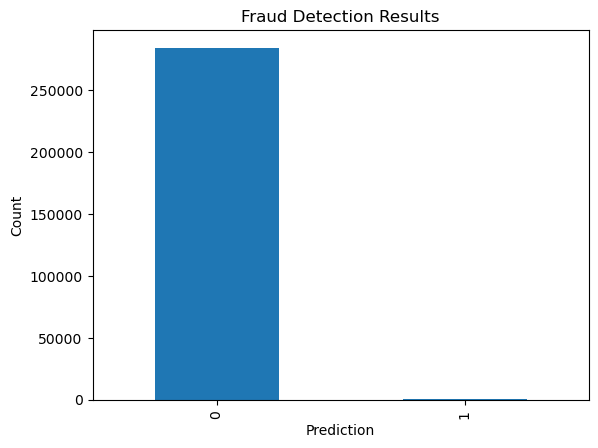

In [28]:
import matplotlib.pyplot as plt

alerts_count = df["Prediction"].value_counts()

alerts_count.plot(kind="bar")

plt.title("Fraud Detection Results")
plt.xlabel("Prediction")
plt.ylabel("Count")

plt.show()

In [29]:
df["Prediction"] = pred.values

alerts = df[df["Prediction"] == 1]

print("Total Alerts:", len(alerts))

alerts.head()

Total Alerts: 485


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Prediction
1632,1264.0,-11.140706,-9.612726,-12.389545,6.013346,-32.092129,21.393069,34.303177,-7.520784,-1.925732,...,1.366110,-2.925888,0.843551,0.746267,0.801387,3.852046,4.157934,7712.43,0,1
2963,2507.0,-6.200114,5.025406,-2.742492,-0.940903,-6.656259,5.432294,-9.198175,-22.588547,-3.244295,...,4.393846,1.943002,0.846005,-1.343379,-0.707634,-0.210219,0.066529,544.62,0,1
4608,3967.0,-7.896534,6.224859,-2.913981,-4.154047,1.171430,2.749061,0.031022,0.749092,7.783716,...,-1.323267,0.366454,0.840169,1.469106,0.786302,3.294538,1.681022,1.46,0,1
5425,5406.0,-8.733429,-5.681953,2.253879,3.930311,-0.916149,4.355297,5.400286,-4.994383,6.819787,...,1.525158,-1.428302,-0.030181,-0.029485,-0.264455,-7.976100,4.712560,553.60,0,1
6624,8130.0,-9.175447,7.906022,-2.068334,-0.901683,-2.178911,4.675277,-8.314425,-22.605711,3.095693,...,-8.483441,3.638520,-0.533970,0.428590,0.222205,1.159270,0.179528,23.98,0,1


In [30]:
df["Prediction"] = pred.values

alerts = df[df["Prediction"] == 1]

df.to_csv("fraud_detection_results.csv", index=False)

print("File saved successfully")

File saved successfully
